<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 164.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 200.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 159.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 161.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 185.1 MB/s eta 0:00:00


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
df.columns
df.dtypes
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


(65437, 114)

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
# Missing values per column
df.isnull().sum()


ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [5]:
# Impute RemoteWork with the most frequent value
df["RemoteWork"] = df["RemoteWork"].fillna(df["RemoteWork"].mode()[0])
# Impute ConvertedCompYearly with the median
df["ConvertedCompYearly"] = df["ConvertedCompYearly"].fillna(
    df["ConvertedCompYearly"].median()
)
# Drop rows with missing JobSat
df = df.dropna(subset=["JobSat"])
df.isnull().sum()


ResponseId               0
MainBranch               0
Age                      0
Employment               0
RemoteWork               0
                      ... 
JobSatPoints_11        117
SurveyLength           406
SurveyEase             374
ConvertedCompYearly      0
JobSat                   0
Length: 114, dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [6]:
df["SurveyEase"] = df["SurveyEase"].fillna(df["SurveyEase"].mode()[0])
df["SurveyLength"] = df["SurveyLength"].fillna(df["SurveyLength"].mode()[0])
df["JobSatPoints_11"] = df["JobSatPoints_11"].fillna(df["JobSatPoints_11"].median())
df[["SurveyEase", "SurveyLength", "JobSatPoints_11"]].isnull().sum()


/tmp/ipykernel_300/849666315.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SurveyEase"] = df["SurveyEase"].fillna(df["SurveyEase"].mode()[0])
/tmp/ipykernel_300/849666315.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SurveyLength"] = df["SurveyLength"].fillna(df["SurveyLength"].mode()[0])
/tmp/ipykernel_300/849666315.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

SurveyEase         0
SurveyLength       0
JobSatPoints_11    0
dtype: int64

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


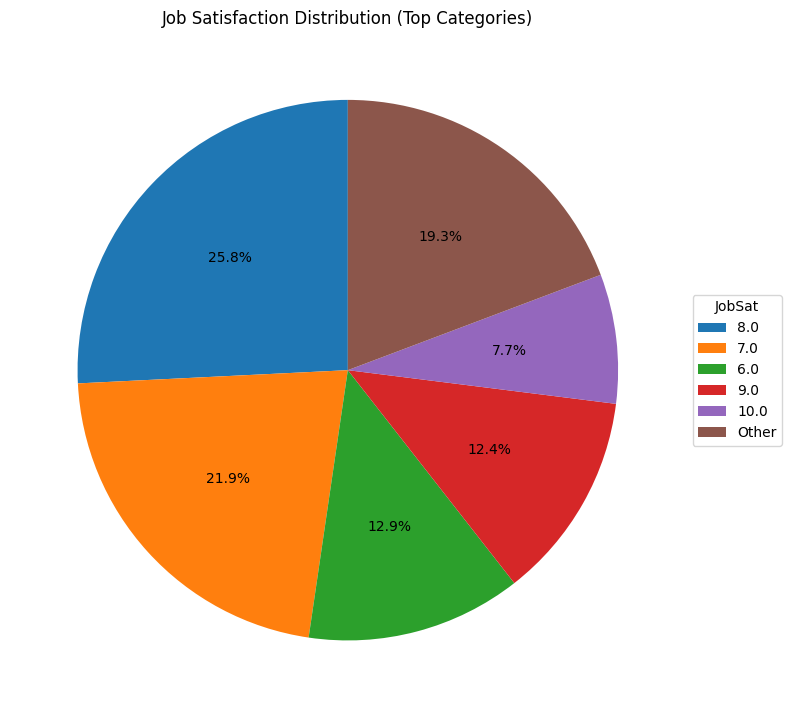

In [8]:
import matplotlib.pyplot as plt

job_counts = df["JobSat"].value_counts()

top_n = 5
top_counts = job_counts.head(top_n)
other_count = job_counts.iloc[top_n:].sum()

plot_counts = top_counts.copy()
if other_count > 0:
    plot_counts["Other"] = other_count

plt.figure(figsize=(8, 8))
plt.pie(plot_counts.values, autopct="%1.1f%%", startangle=90)
plt.title("Job Satisfaction Distribution (Top Categories)")
plt.legend(plot_counts.index, title="JobSat", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


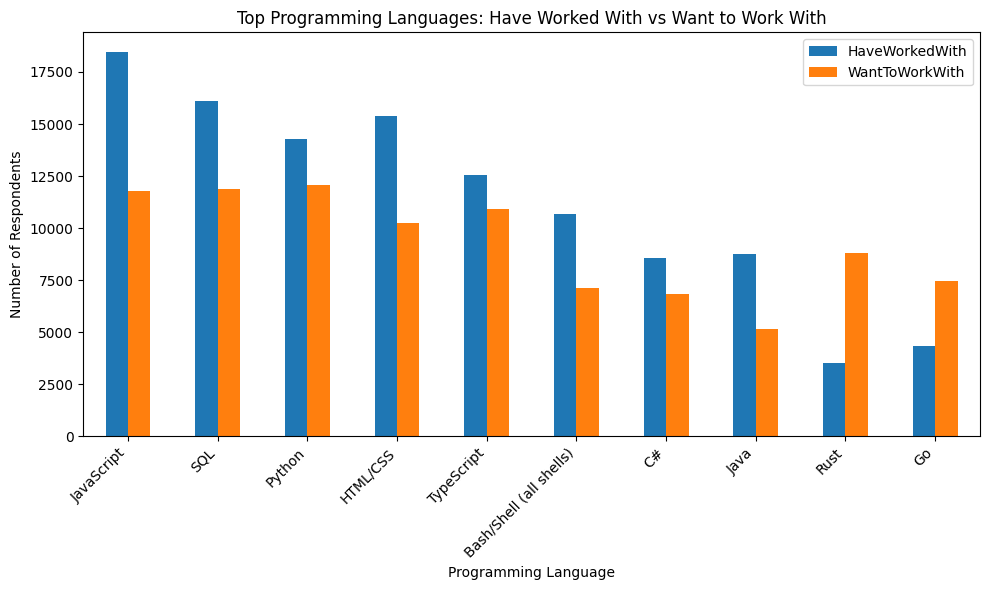

,HaveWorkedWith,WantToWorkWith
JavaScript,18480,11775
SQL,16104,11884
Python,14289,12056
HTML/CSS,15371,10239
TypeScript,12559,10909
Bash/Shell (all shells),10687,7117
C#,8571,6859
Java,8734,5168
Rust,3514,8821
Go,4350,7457


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data (split + explode)
have = df[["LanguageHaveWorkedWith"]].dropna().copy()
have["LanguageHaveWorkedWith"] = have["LanguageHaveWorkedWith"].str.split(";")
have = have.explode("LanguageHaveWorkedWith")

want = df[["LanguageWantToWorkWith"]].dropna().copy()
want["LanguageWantToWorkWith"] = want["LanguageWantToWorkWith"].str.split(";")
want = want.explode("LanguageWantToWorkWith")

# Frequency counts
have_counts = have["LanguageHaveWorkedWith"].value_counts()
want_counts = want["LanguageWantToWorkWith"].value_counts()

# Compare top N languages (based on combined popularity)
top_n = 10
top_langs = (have_counts.add(want_counts, fill_value=0)).sort_values(ascending=False).head(top_n).index

compare_df = pd.DataFrame({
    "HaveWorkedWith": have_counts.reindex(top_langs, fill_value=0),
    "WantToWorkWith": want_counts.reindex(top_langs, fill_value=0)
})

# Grouped bar chart
ax = compare_df.plot(kind="bar", figsize=(10, 6))
plt.title("Top Programming Languages: Have Worked With vs Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

compare_df


In [11]:
# Create sets of top languages (Top 10 in each)
top_have_set = set(have_counts.head(10).index)
top_want_set = set(want_counts.head(10).index)

top_have_set, top_want_set, len(top_have_set & top_want_set)


({'Bash/Shell (all shells)',
  'C#',
  'C++',
  'HTML/CSS',
  'Java',
  'JavaScript',
  'PHP',
  'Python',
  'SQL',
  'TypeScript'},
 {'Bash/Shell (all shells)',
  'C#',
  'Go',
  'HTML/CSS',
  'Java',
  'JavaScript',
  'Python',
  'Rust',
  'SQL',
  'TypeScript'},
 8)

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [12]:
regions = {
    "North America": ["United States of America", "United States", "Canada", "Mexico"],
    "Europe": ["United Kingdom", "Germany", "France", "Italy", "Spain", "Netherlands", "Sweden", "Poland"],
    "Asia": ["India", "China", "Japan", "South Korea", "Singapore", "Pakistan", "Bangladesh"],
    "Middle East": ["Lebanon", "Saudi Arabia", "United Arab Emirates", "Jordan", "Iraq", "Kuwait", "Qatar"],
    "Africa": ["Nigeria", "Egypt", "South Africa", "Kenya", "Morocco", "Algeria", "Tunisia"],
    "South America": ["Brazil", "Argentina", "Chile", "Colombia", "Peru"]
}

def map_region(country):
    for region, countries in regions.items():
        if country in countries:
            return region
    return "Other"

df["Region"] = df["Country"].apply(map_region)


In [13]:
remote_region = pd.crosstab(df["Region"], df["RemoteWork"])
remote_region


RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Region,,,
Africa,227,123,220
Asia,1097,1107,655
Europe,3756,1083,2049
Middle East,45,75,38
North America,2336,924,3496
Other,4885,1927,3918
South America,285,153,727


In [15]:
remote_region_pct = pd.crosstab(df["Region"], df["RemoteWork"], normalize="index") * 100
remote_region_pct


RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Region,,,
Africa,39.824561,21.578947,38.596491
Asia,38.370059,38.719832,22.910108
Europe,54.529617,15.722997,29.747387
Middle East,28.481013,47.468354,24.050633
North America,34.576673,13.676732,51.746596
Other,45.526561,17.958993,36.514445
South America,24.463519,13.133047,62.403433


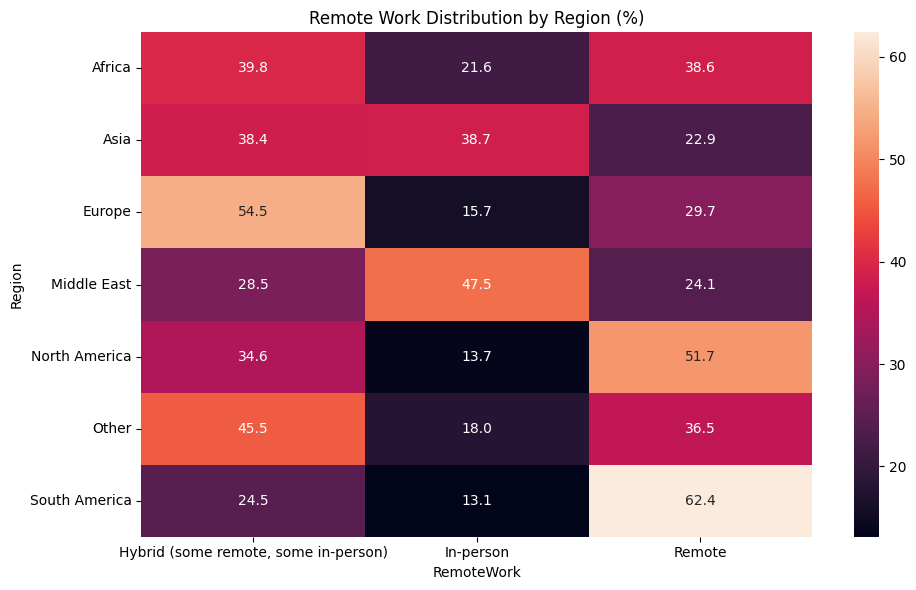

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(remote_region_pct, annot=True, fmt=".1f")
plt.title("Remote Work Distribution by Region (%)")
plt.xlabel("RemoteWork")
plt.ylabel("Region")
plt.tight_layout()
plt.show()


### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [17]:
import pandas as pd

df["YearsCodePro_Num"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 50
})
df["YearsCodePro_Num"] = pd.to_numeric(df["YearsCodePro_Num"], errors="coerce")
job_sat_map = {
    "Very dissatisfied": 1,
    "Slightly dissatisfied": 2,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly satisfied": 4,
    "Very satisfied": 5
}

df["JobSat_Score"] = df["JobSat"].map(job_sat_map)
corr_df = df[["YearsCodePro_Num", "JobSat_Score"]].dropna()

spearman_corr = corr_df["YearsCodePro_Num"].corr(corr_df["JobSat_Score"], method="spearman")
pearson_corr  = corr_df["YearsCodePro_Num"].corr(corr_df["JobSat_Score"], method="pearson")

print("Spearman correlation:", spearman_corr)
print("Pearson correlation:", pearson_corr)


Spearman correlation: nan
Pearson correlation: nan


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


/tmp/ipykernel_300/1282750958.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


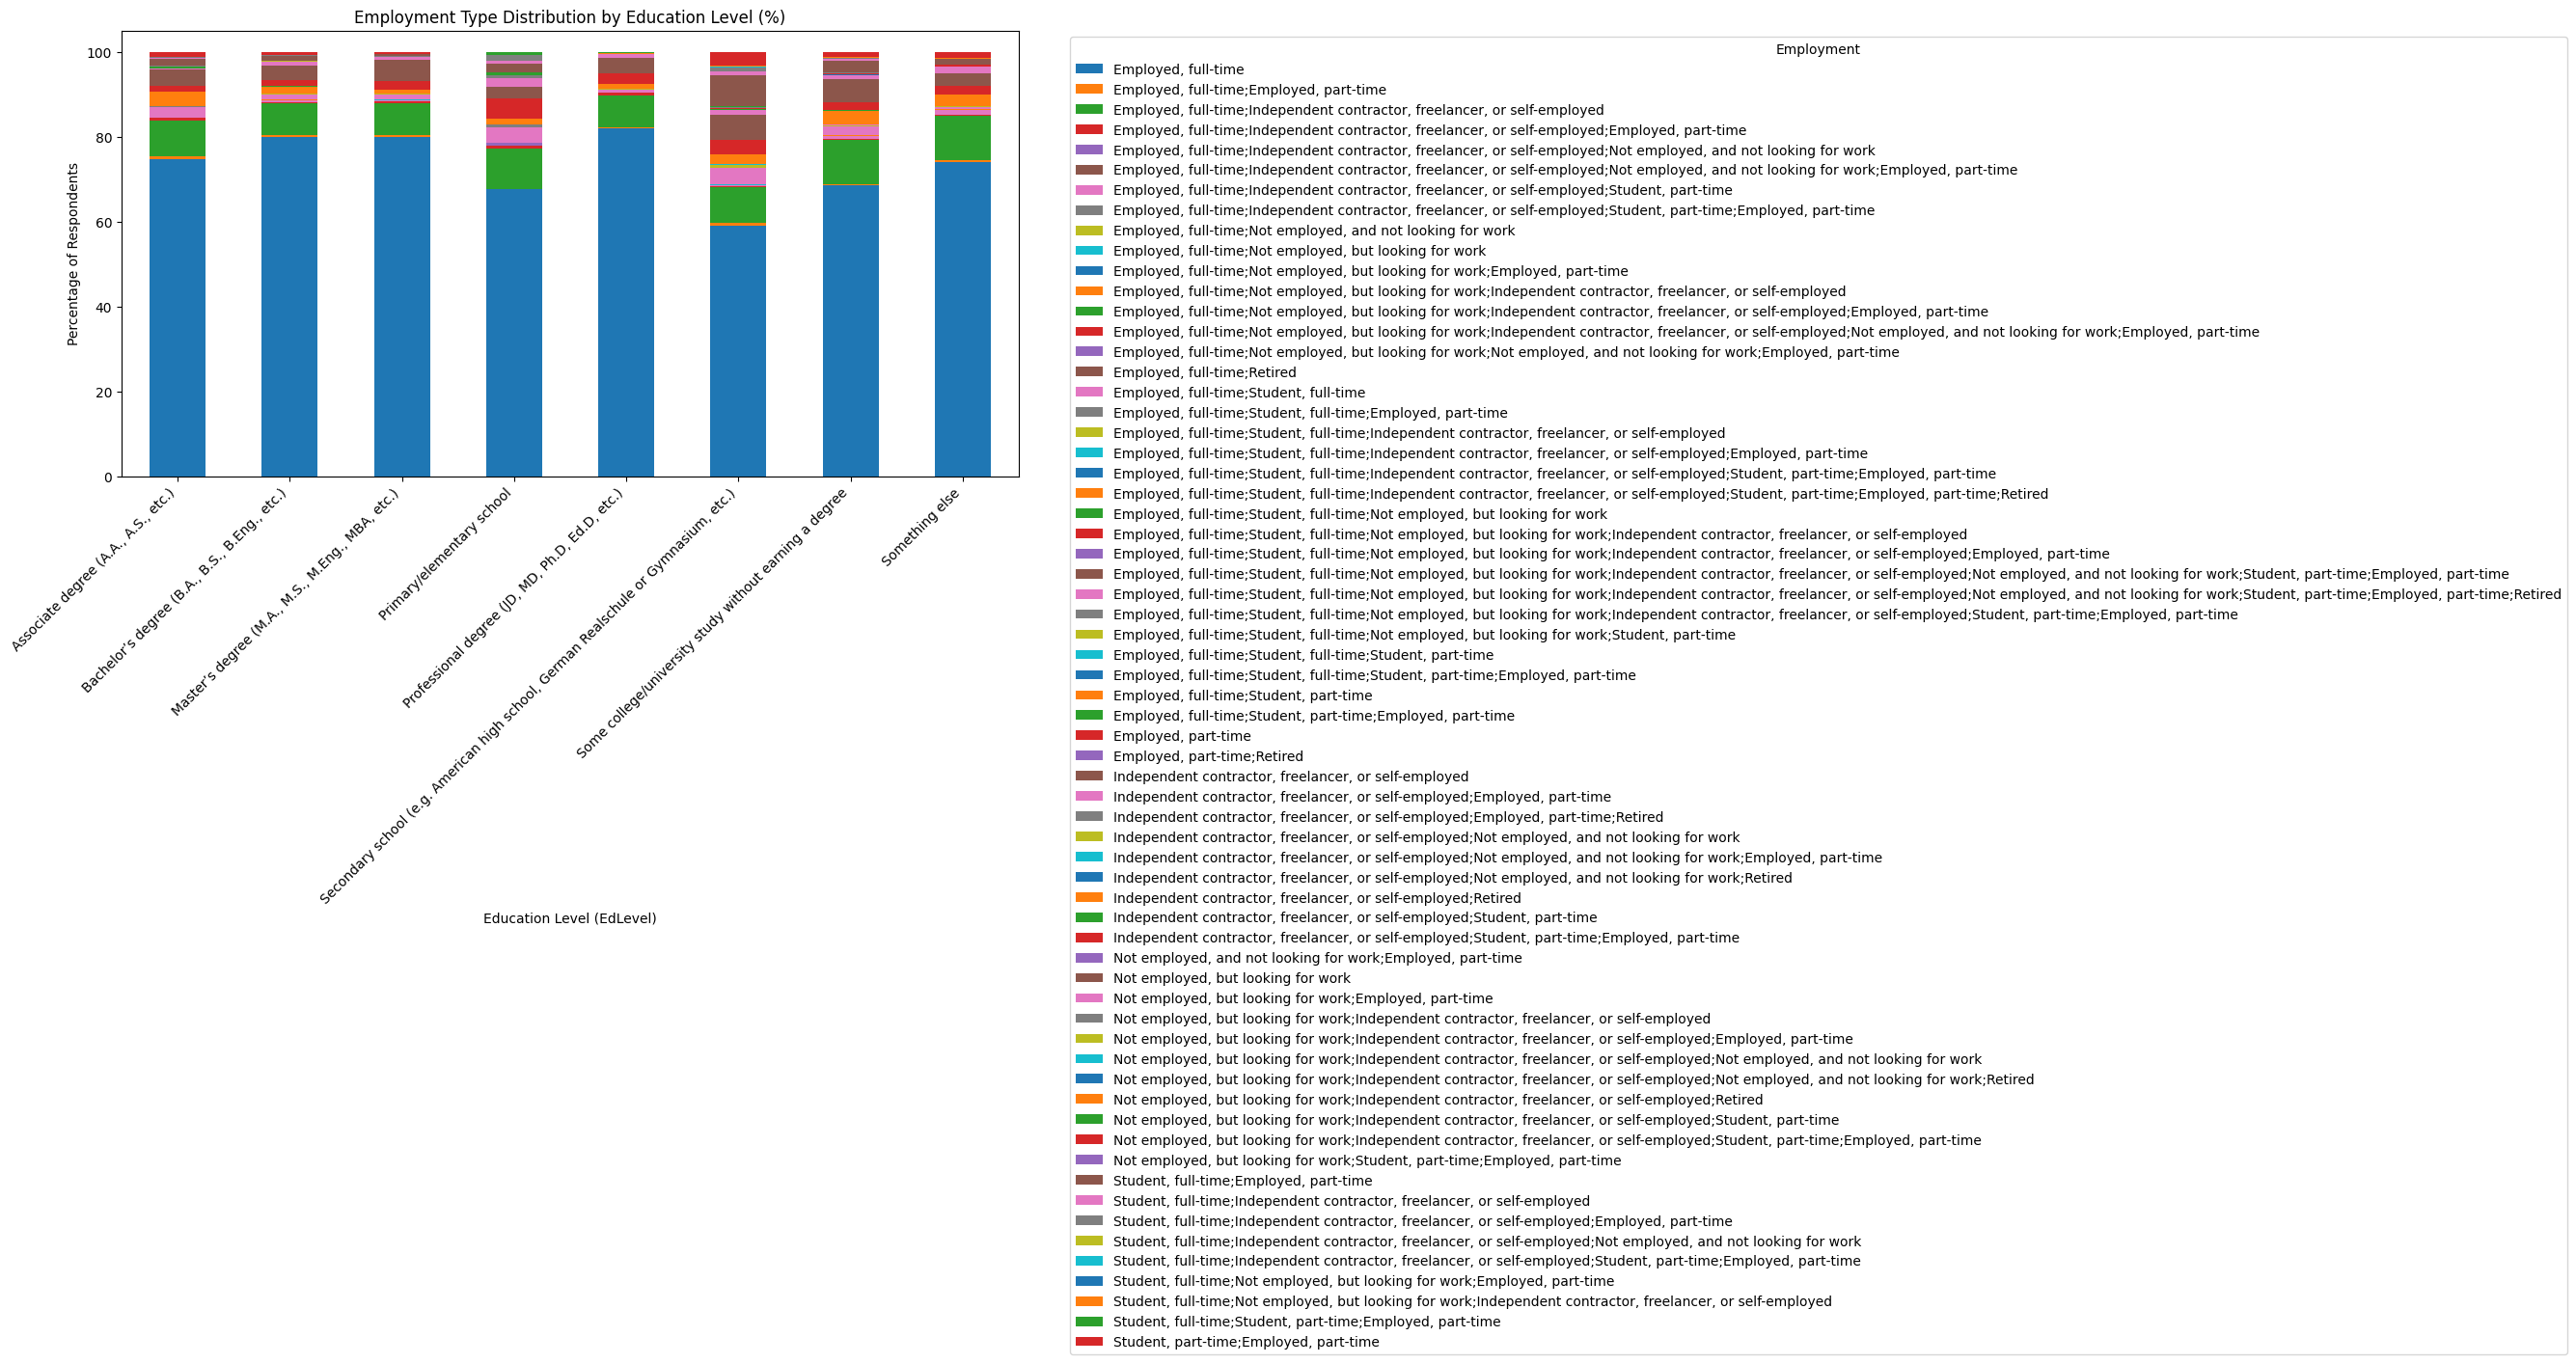

In [18]:
ct = pd.crosstab(df["EdLevel"], df["Employment"])
ct
ct_pct = pd.crosstab(df["EdLevel"], df["Employment"], normalize="index") * 100
ct_pct
import matplotlib.pyplot as plt

ct_pct.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Employment Type Distribution by Education Level (%)")
plt.xlabel("Education Level (EdLevel)")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Employment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [19]:
# Export cleaned dataset to CSV
df.to_csv("cleaned_survey_data.csv", index=False)


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
